In [1]:
#Importation des librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1 - Préparation de données 

In [2]:
#Résultats européennes et legislatives

eur24 = pd.read_csv("res_europeennes_24.csv",sep=";",encoding="ISO-8859-1")

leg24 = pd.read_csv("res_legislatives_24.csv",sep=";",encoding="ISO-8859-1")



In [3]:
eur24.columns

Index(['ï»¿id_bv', 'num_circ', 'nom_quartier', 'num_arrond', 'nb_procu',
       'nb_inscr', 'nb_abscent', 'taux_ab', 'nb_emarg', 'nb_votant',
       'nb_blanc_null', 'nb_exprim', 'NB_ExtGauche', 'NB_Gauche', 'NB_Centre',
       'NB_Droite', 'NB_ExtDroite', 'NB_Divers', 'Unnamed: 18', 'LFI/Gauche',
       'LFI/PS', 'LFI/EELV', 'EELV/PS', 'LFI/RN'],
      dtype='object')

In [4]:
leg24.columns

Index(['ï»¿id_bv', 'num_circ', 'nom_quartier', 'num_arrond', 'nb_procu',
       'nb_inscr', 'nb_abscent', 'taux_ab', 'nb_emarg', 'nb_votant', 'nb_bl',
       'nb_nul', 'nb_exprim', 'NB_ExtGauche', 'NB_Gauche', 'NB_Centre',
       'NB_Droite', 'NB_ExtDroite', 'NB_Divers'],
      dtype='object')

In [5]:
#Récupération des voix de gauche 


gauche_eur = eur24[['ï»¿id_bv','NB_ExtGauche', 'NB_Gauche']]

gauche_leg = leg24[['ï»¿id_bv','NB_ExtGauche', 'NB_Gauche']]


In [6]:
gauche_eur.head(5)

,ï»¿id_bv,NB_ExtGauche,NB_Gauche
0,01_01,0,157
1,01_02,1,157
2,01_03,1,188
3,01_04,3,211
4,01_05,1,164


In [7]:
gauche_leg.head(5)

,ï»¿id_bv,NB_ExtGauche,NB_Gauche
0,01_01,3.0,279.0
1,01_02,0.0,312.0
2,01_03,8.0,315.0
3,01_04,18.0,416.0
4,01_05,1.0,320.0


In [8]:
#Additionner les voix de gauches pour ces deux élections

total_gauche_eur = np.sum(gauche_eur['NB_ExtGauche'])+ np.sum(gauche_eur['NB_Gauche'])

total_gauche_leg = np.sum(gauche_leg['NB_ExtGauche'])+ np.sum(gauche_leg['NB_Gauche'])

voix_gauche = [total_gauche_eur,total_gauche_leg]

voix_gauche = pd.DataFrame(voix_gauche).T

voix_gauche = voix_gauche.rename(columns = {0:'européennes',1:'législative'})

In [9]:
voix_gauche

,européennes,législative
0,242943.0,456667.0


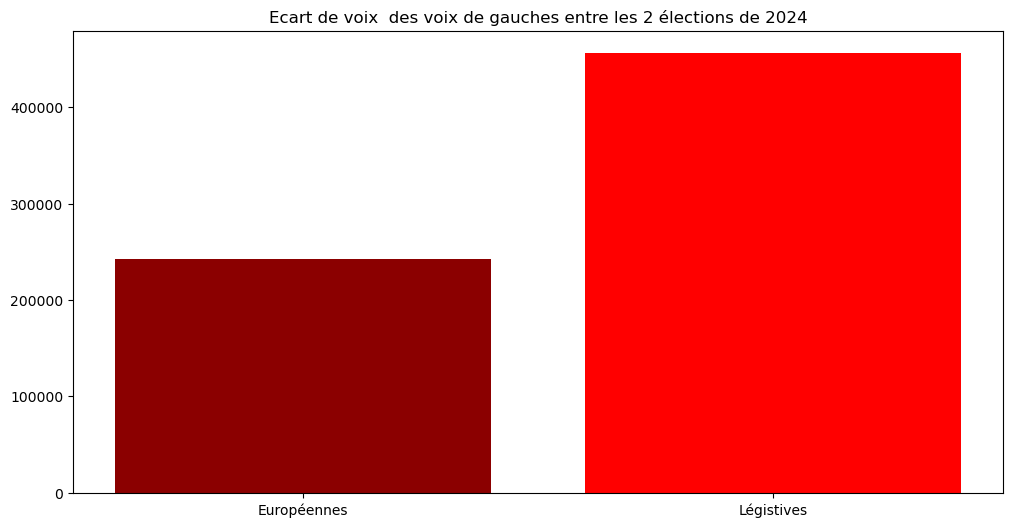

In [10]:
plt.figure(figsize=(12,6))

names = ['Européennes','Légistives']

values = [242943,456667]


plt.bar(names,values,color = ['darkred','red']) 
plt.title("Ecart de voix  des voix de gauches entre les 2 élections de 2024")

plt.show()

# 2 - Analyse par bureau de vote 


Nous allons analyser les différents résultats des voix de gauches en fonction des bureaux de vote 

In [11]:
#Ouverture du ficher des voix de gauche

gauche = pd.read_csv('res_gauche.csv',sep=';',encoding='ISO-8859-1')


#indexation de la 1er colonne
gauche = gauche.set_index('ï»¿id_bv',drop='True')


gauche.head(5)

,total_G_EUR,total_G_LEG,rap_G_LEG/EUR,nb_PS,nb_EELV,nb_PCF,nb_LFI,autresGauche,ExtGauche,partie_dominant
ï»¿id_bv,,,,,,,,,,
01_01,295,282,"0,96",136,66,4,84,3,2,Partie Socialiste
01_02,329,312,"0,95",171,72,5,71,9,1,Partie Socialiste
01_03,369,323,"0,88",178,86,11,86,5,3,Partie Socialiste
01_04,390,434,"1,11",175,66,15,125,5,4,Partie Socialiste
01_05,338,321,"0,95",173,79,5,75,5,1,Partie Socialiste


### 2-1 Les parties de gauches 

Pour analyser les différentes parties politiques , on utilisera seulement les voix des éléctions européennes de 2024 pour cause qu'il n'y a pas de sur/sous-représenttaion des votes ainsi des alliance politiques 

In [12]:
partie_gauche = [np.sum(gauche['ExtGauche']),
                 np.sum(gauche["nb_LFI"]),
                 np.sum(gauche["nb_PCF"]),
                 np.sum(gauche["nb_EELV"]),
                 np.sum(gauche["nb_PS"]),
                 np.sum(gauche["autresGauche"])]

partie_gauche

[3651, 136507, 11312, 87186, 186178, 5665]

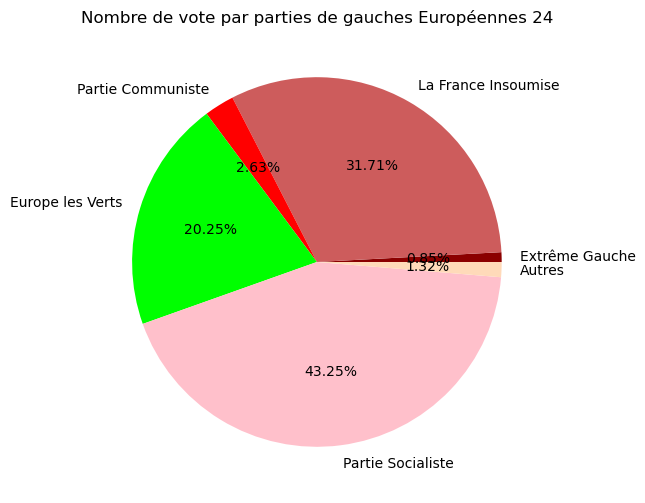

In [13]:
#Diagramme circulaire
plt.figure(figsize=(10,6))

plt.pie(partie_gauche,labels = ["Extrême Gauche",
                                 "La France Insoumise",
                                 "Partie Communiste",
                                 "Europe les Verts",
                                 "Partie Socialiste",
                                 "Autres"], colors = ['darkred','indianred','red','lime','pink','peachpuff'], autopct = '%.2f%%')

plt.title('Nombre de vote par parties de gauches Européennes 24')
plt.savefig("eur24_res_gauches.png")

plt.show()

In [14]:
#dominantion par bureau de vote

nb_part = gauche["partie_dominant"].value_counts()

nb_part

partie_dominant
Partie Socialiste      701
La France Insoumise    201
Name: count, dtype: int64

Text(0.5, 1.0, 'Nombre de bureau de vote gagnées selon les parties gauches')

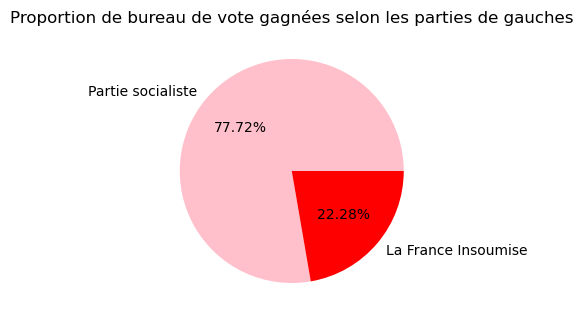

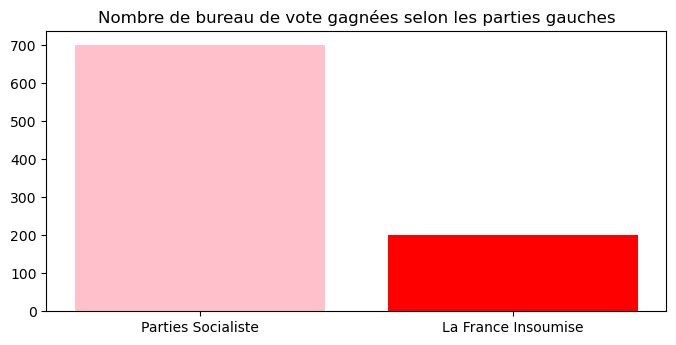

In [15]:

nb_part = [701,201]

# Représentation grahiques 


plt.figure(figsize=(8,8))
plt.subplot(2,1,1)
plt.pie(nb_part,labels = ["Partie socialiste",
                                 "La France Insoumise"], colors = ['pink','red'], autopct = '%.2f%%')
plt.title('Proportion de bureau de vote gagnées selon les parties de gauches')



plt.figure(figsize=(8,8))
plt.subplot(2,1,2)
plt.bar(["Parties Socialiste","La France Insoumise"],nb_part,color = ['pink','red']) 
plt.title("Nombre de bureau de vote gagnées selon les parties gauches")


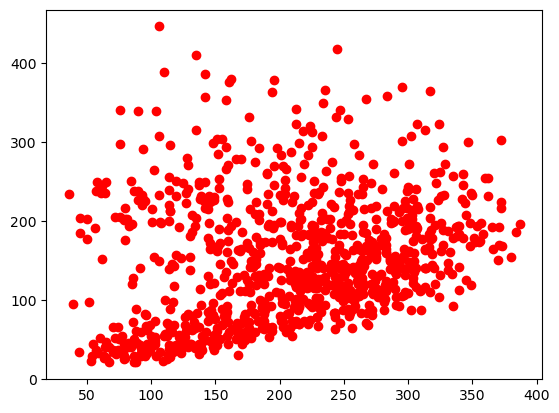

In [16]:
#Représentation graphiques 

plt.plot(gauche["nb_PS"],gauche["nb_LFI"],'or') 

plt.show()

Avec ce nuage de point initiales on peut pas exprimer une liaison entre les différentes votes des deux parties. 

L'idée maintenant est de voire les écart absolue des nombre de voix entres les deux parties de la  gauche 

#### 2-2 Ecart de voix entre les deux parties 


On utilisera les voix des deux parties lors des élections européenes de 2024 



In [26]:
gauche["rap_LFI_PS"] = np.round(gauche["nb_LFI"]/gauche["nb_PS"],2)

In [27]:
gauche["rap_LFI_PS"]

ï»¿id_bv
01_01    0.62
01_02    0.42
01_03    0.48
01_04    0.71
01_05    0.43
         ... 
20_72    1.93
20_73    1.05
20_74    1.15
20_75    2.72
20_76    1.70
Name: rap_LFI_PS, Length: 902, dtype: float64

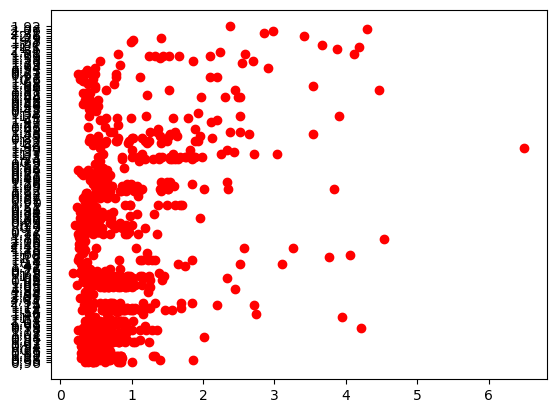

In [28]:
#Représentation graphiques 

plt.plot(gauche["rap_LFI_PS"],gauche["rap_G_LEG/EUR"],'or') 

plt.show()

il y a pas le lien entre le rapport des voix des parties LFI et le PS, et le taux d'abstention par bureau de vote
